In [1]:
# analyse different systems with the same spectral radius and see how the vector orthogonal to the subspace develops

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat, len_new_orth_vec, len_new_orth_vec_new_not_norm, get_time_of_threshold_crossing, exp_func, stable_trials

In [3]:
spec_rad = 1.4
time_steps = 70

Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
#trial=6
fixed_whh=True
fixed_wih=True

x_vals = np.arange(1,70)

In [4]:
x_vals = np.arange(1,70)
#fig, ax = plt.subplots(10,5, figsize=(25,50), sharey=True, sharex=True)

orth_vec_lens = np.zeros((50, Hippo_n_feature, time_steps-1))

for t in range(50):
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=i)
        try:
            len_orth_vectors = len_new_orth_vec(hs, time_steps)
            #ax[t//5, t%5].scatter(x_vals, len_orth_vectors, label=f'{i}', s=5)
            orth_vec_lens[t, i, :] = len_orth_vectors
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for trial {t} and input neuron {i}: {e}')
            pass
        #ax[t//5, t%5].set_title(f'{t}')

Could not compute length of orthogonal vectors for trial 24 and input neuron 5: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).
Could not compute length of orthogonal vectors for trial 38 and input neuron 6: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).


In [5]:
orth_vec_lens_not_norm = np.zeros((50, Hippo_n_feature, time_steps-1))

for t in range(50):
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=i)
        try:
            len_orth_vectors = len_new_orth_vec_new_not_norm(hs, time_steps)
            #ax[t//5, t%5].scatter(x_vals, len_orth_vectors, label=f'{i}', s=5)
            orth_vec_lens_not_norm[t, i, :] = len_orth_vectors
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for trial {t} and input neuron {i}: {e}')
            pass

Could not compute length of orthogonal vectors for trial 46 and input neuron 10: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).


In [6]:
thresh_crossed = get_time_of_threshold_crossing(orth_vec_lens)
print(thresh_crossed)

thresh_crossed_not_norm = get_time_of_threshold_crossing(orth_vec_lens_not_norm)
print(thresh_crossed_not_norm)

[12. 28. 19. 27. 27. 19. 18. 18. 38. 27. 12. 26. 26. 14. 49. 26. 10. 25.
 24. 13. 13. 11. 29. 50. 15. 14. 10. 14. 17. 12. 13.  9. 11. 22.  8. 21.
 17. 11. 24. 49. 22. 20. 14. 18. 15. 41. 12. 15. 11. 20.]
[15. 14. 22. 10. 17. 17. 12. 13. 11. 11. 18. 12. 20. 11. 11. 19. 18. 13.
 14. 32. 19. 35. 12.  8. 11. 35. 16. 12. 18. 14. 11. 16. 20. 21. 25. 17.
 14. 17. 16.  7. 15. 15. 12. 10. 17. 12. 32. 20. 16. 20.]


In [7]:
# fit an exponential curve to the length of the orthogonal vector over time
a_vals = np.zeros(50)
tau_vals = np.zeros(50)
y_vals = np.zeros((50, time_steps-1))
ys = orth_vec_lens.copy()

for t in range(50):
    a0 = orth_vec_lens[t, 0, 0]
    tau0 = 5.0
    popt, pcov = curve_fit(exp_func, x_vals, ys[t, 0, :], p0=[a0, tau0])
    a_fit, tau_fit = popt
    a_vals[t] = a_fit
    tau_vals[t] = tau_fit
    y_vals[t, :] = exp_func(x_vals, a_fit, tau_fit)

In [8]:
# fit an exponential curve to the length of the orthogonal vector over time
a_vals_not_norm = np.zeros(50)
tau_vals_not_norm = np.zeros(50)
y_vals_not_norm = np.zeros((50, time_steps-1))
ys_not_norm = orth_vec_lens_not_norm.copy()

for t in range(50):
    a0_not_norm = orth_vec_lens_not_norm[t, 0, 0]
    tau0_not_norm = 5.0
    popt, pcov = curve_fit(exp_func, x_vals, ys_not_norm[t, 0, :], p0=[a0_not_norm, tau0_not_norm])
    a_fit_not_norm, tau_fit_not_norm = popt
    a_vals_not_norm[t] = a_fit_not_norm
    tau_vals_not_norm[t] = tau_fit_not_norm
    y_vals_not_norm[t, :] = exp_func(x_vals, a_fit_not_norm, tau_fit_not_norm)

#print(y_vals_not_norm)

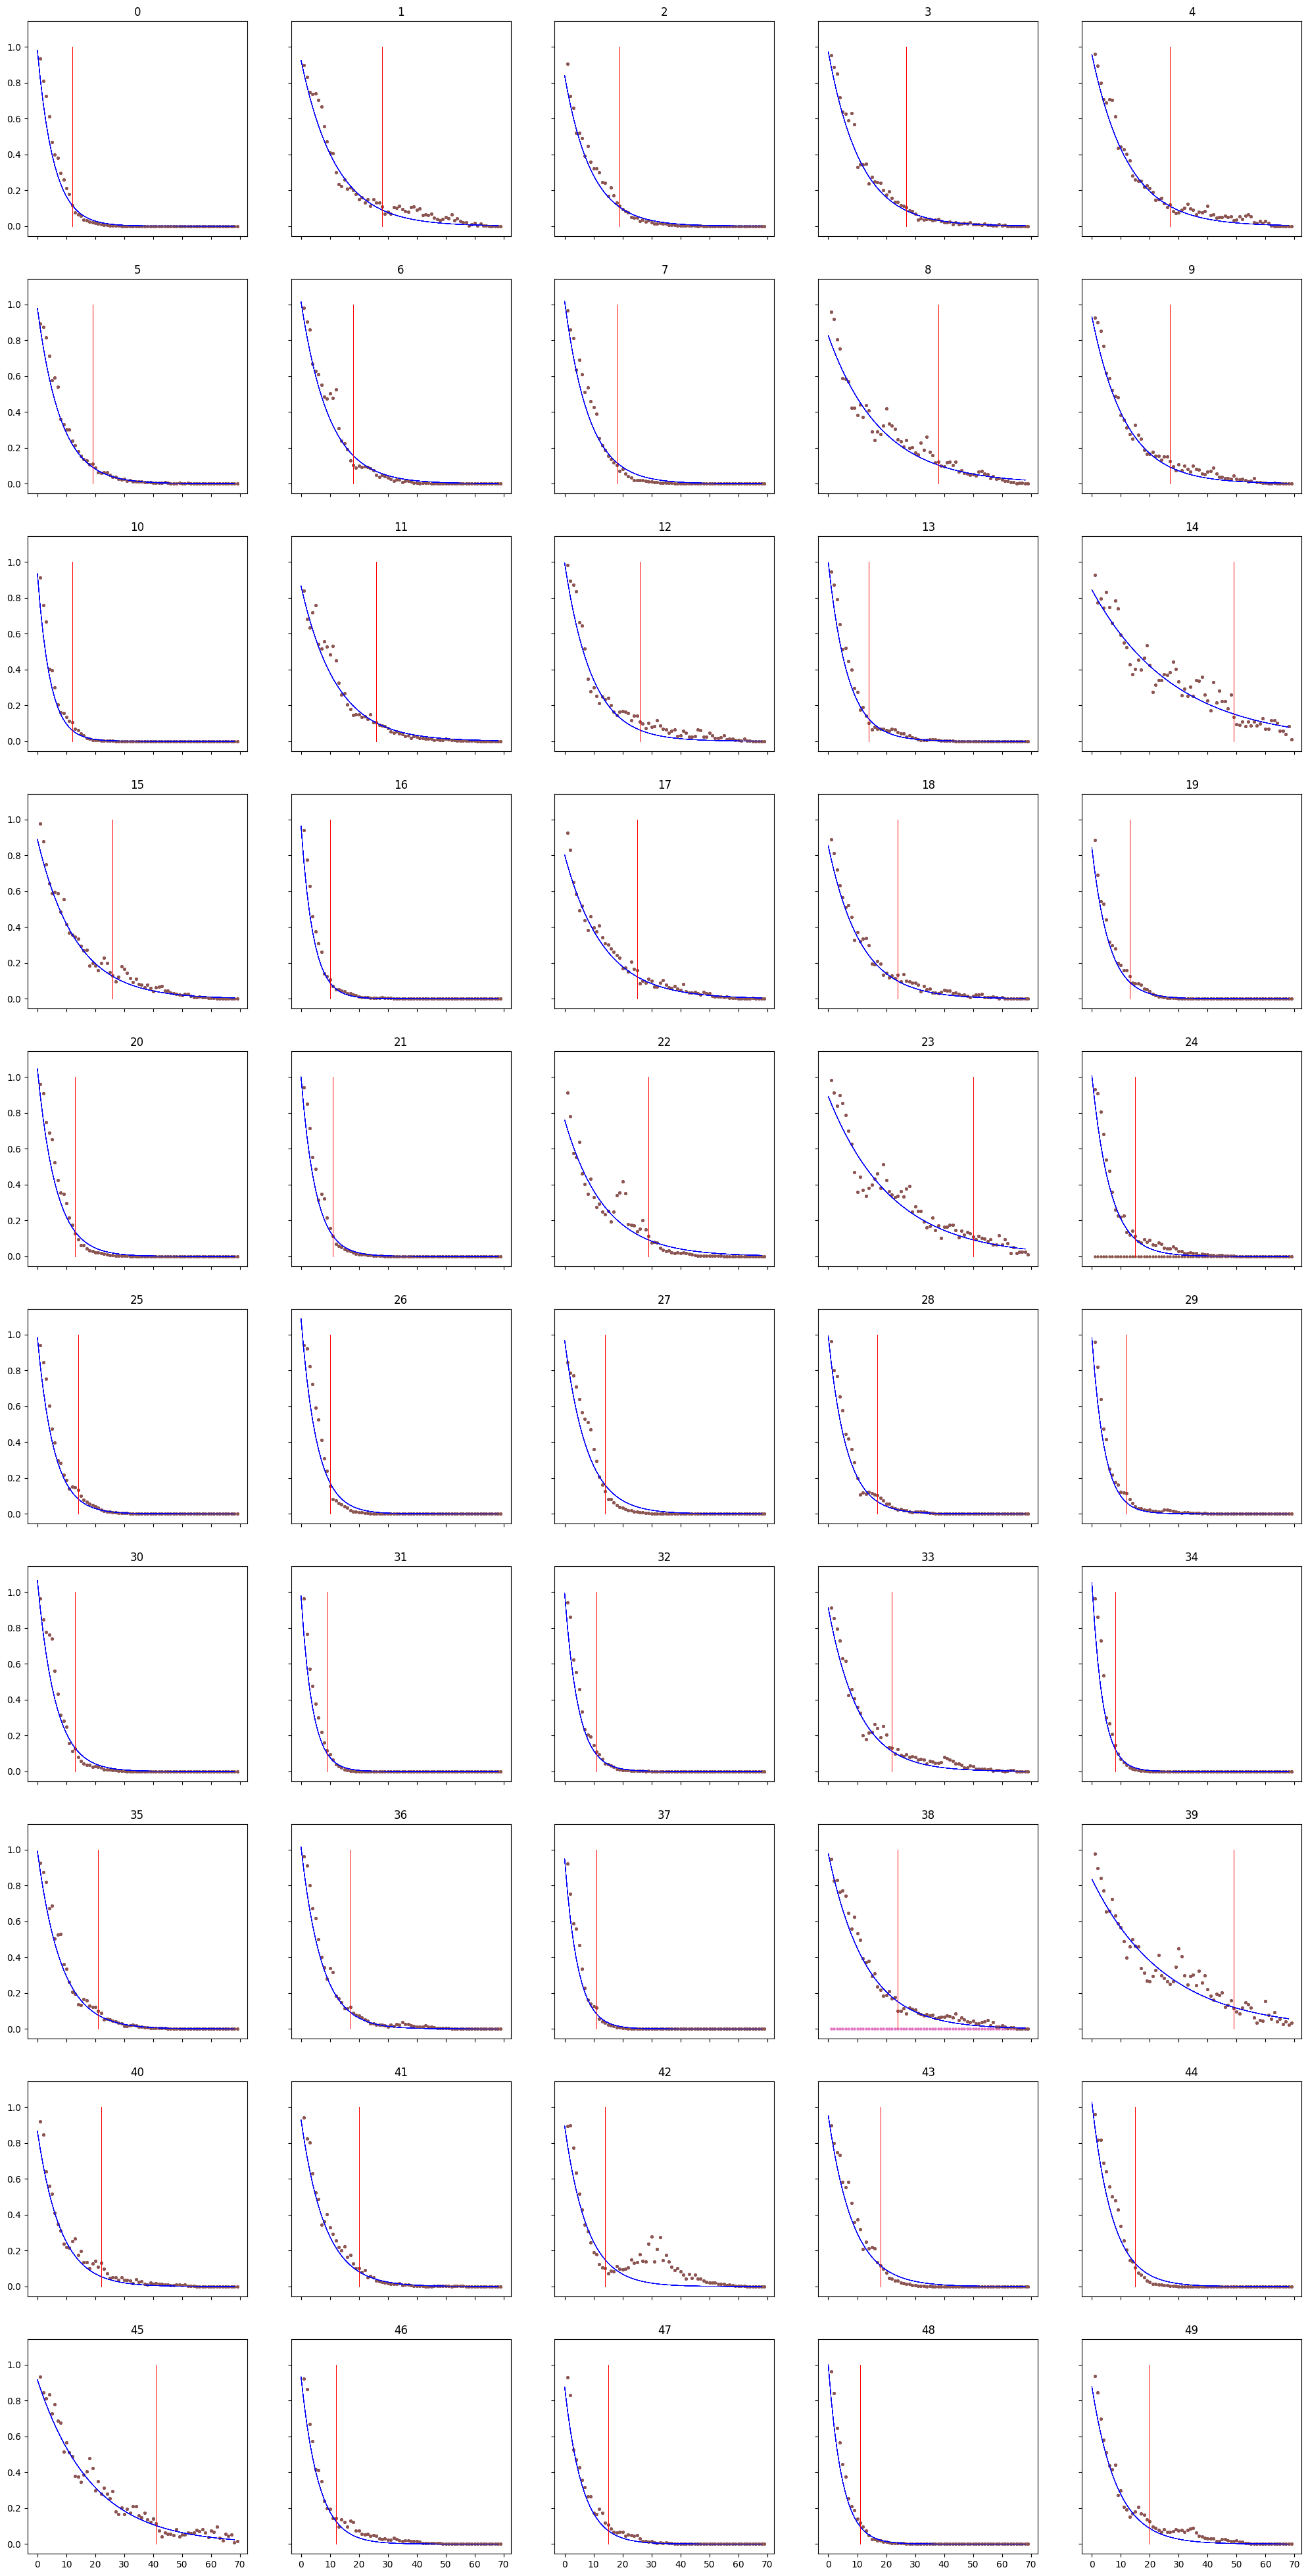

In [9]:
# plot the lengths of the orthogonal vectors
fig, ax = plt.subplots(10,5, figsize=(25,50), sharey=True, sharex=True)
for t in range(50):
    for i in range(Hippo_n_feature):
        ax[t//5, t%5].scatter(x_vals, orth_vec_lens[t, i, :], label=f'{i}', s=5)
        ax[t//5, t%5].plot(y_vals[t, :], c='b',linewidth=0.5)
        ax[t//5, t%5].set_title(f'{t}')
        ax[t//5, t%5].vlines(thresh_crossed[t], ymin=0, ymax=1, colors='r', linewidths=0.5)

In [10]:
trials = [14, 23, 39, 45, 46, 47, 49]
for t in trials:
    #print(f'threshhold was crossed in trial {t}: {thresh_crossed[t]}')
    print(thresh_crossed[t])
    #print(f'tau in trial {t} was: {tau_vals[t]}')
    print(tau_vals[t])

49.0
28.56261768246338
50.0
22.010948594309575
49.0
25.324780577768575
41.0
18.760706704758295
12.0
6.062420022056923
15.0
6.11607142081121
20.0
8.657687758888732


In [11]:
neuron_norms_for_srs = np.zeros((50, time_steps))

for t in range(50):
    #for i in range(Hippo_n_feature):
    hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=0)
      
    neuron_norms_for_srs[t, :] = hs.norm(dim=1)
        

In [12]:
# get the trials sorted by their tau values and threshold crossing times
idx_sorted_tau = np.argsort(-tau_vals)
idx_sorted_thresh_crossed = np.argsort(-thresh_crossed)

print(idx_sorted_tau)
#print(tau_vals[idx_sorted_tau])
print(idx_sorted_thresh_crossed)
#print(thresh_crossed[idx_sorted_thresh_crossed])

[14 39 23 45  8 22 17 15 38  4 11  1  9  3 18 33  6 12  2 49 43  7 41 35
  5 40 42 27 44 36 13 20 24 28 30 47 46 19 25  0 26 21 48 32 37 10 29 16
 31 34]
[23 14 39 45  8 22  1  9  4  3 12 15 11 17 18 38 33 40 35 41 49  2  5 43
  7  6 36 28 47 44 24 13 42 25 27 30 20 19  0 10 29 46 37 21 48 32 16 26
 31 34]


In [13]:
# see the stable trials sorted by their tau values and threshold crossing times
stable_trials_idx = stable_trials(neuron_norms_for_srs)
print(stable_trials_idx)
print('######################################')

m = np.isin(idx_sorted_tau, stable_trials_idx)
stable_sorted_tau = idx_sorted_tau[m]
print(stable_sorted_tau)

m = np.isin(idx_sorted_thresh_crossed, stable_trials_idx)
stable_sorted_thresh = idx_sorted_thresh_crossed[m]
print(stable_sorted_thresh)

[ 1  3  4  5  6  7  8  9 11 12 13 14 15 17 18 22 23 24 27 28 29 30 33 35
 36 38 39 40 41 42 43 45 47 49]
######################################
[14 39 23 45  8 22 17 15 38  4 11  1  9  3 18 33  6 12 49 43  7 41 35  5
 40 42 27 36 13 24 28 30 47 29]
[23 14 39 45  8 22  1  9  4  3 12 15 11 17 18 38 33 40 35 41 49  5 43  7
  6 36 28 47 24 13 42 27 30 29]


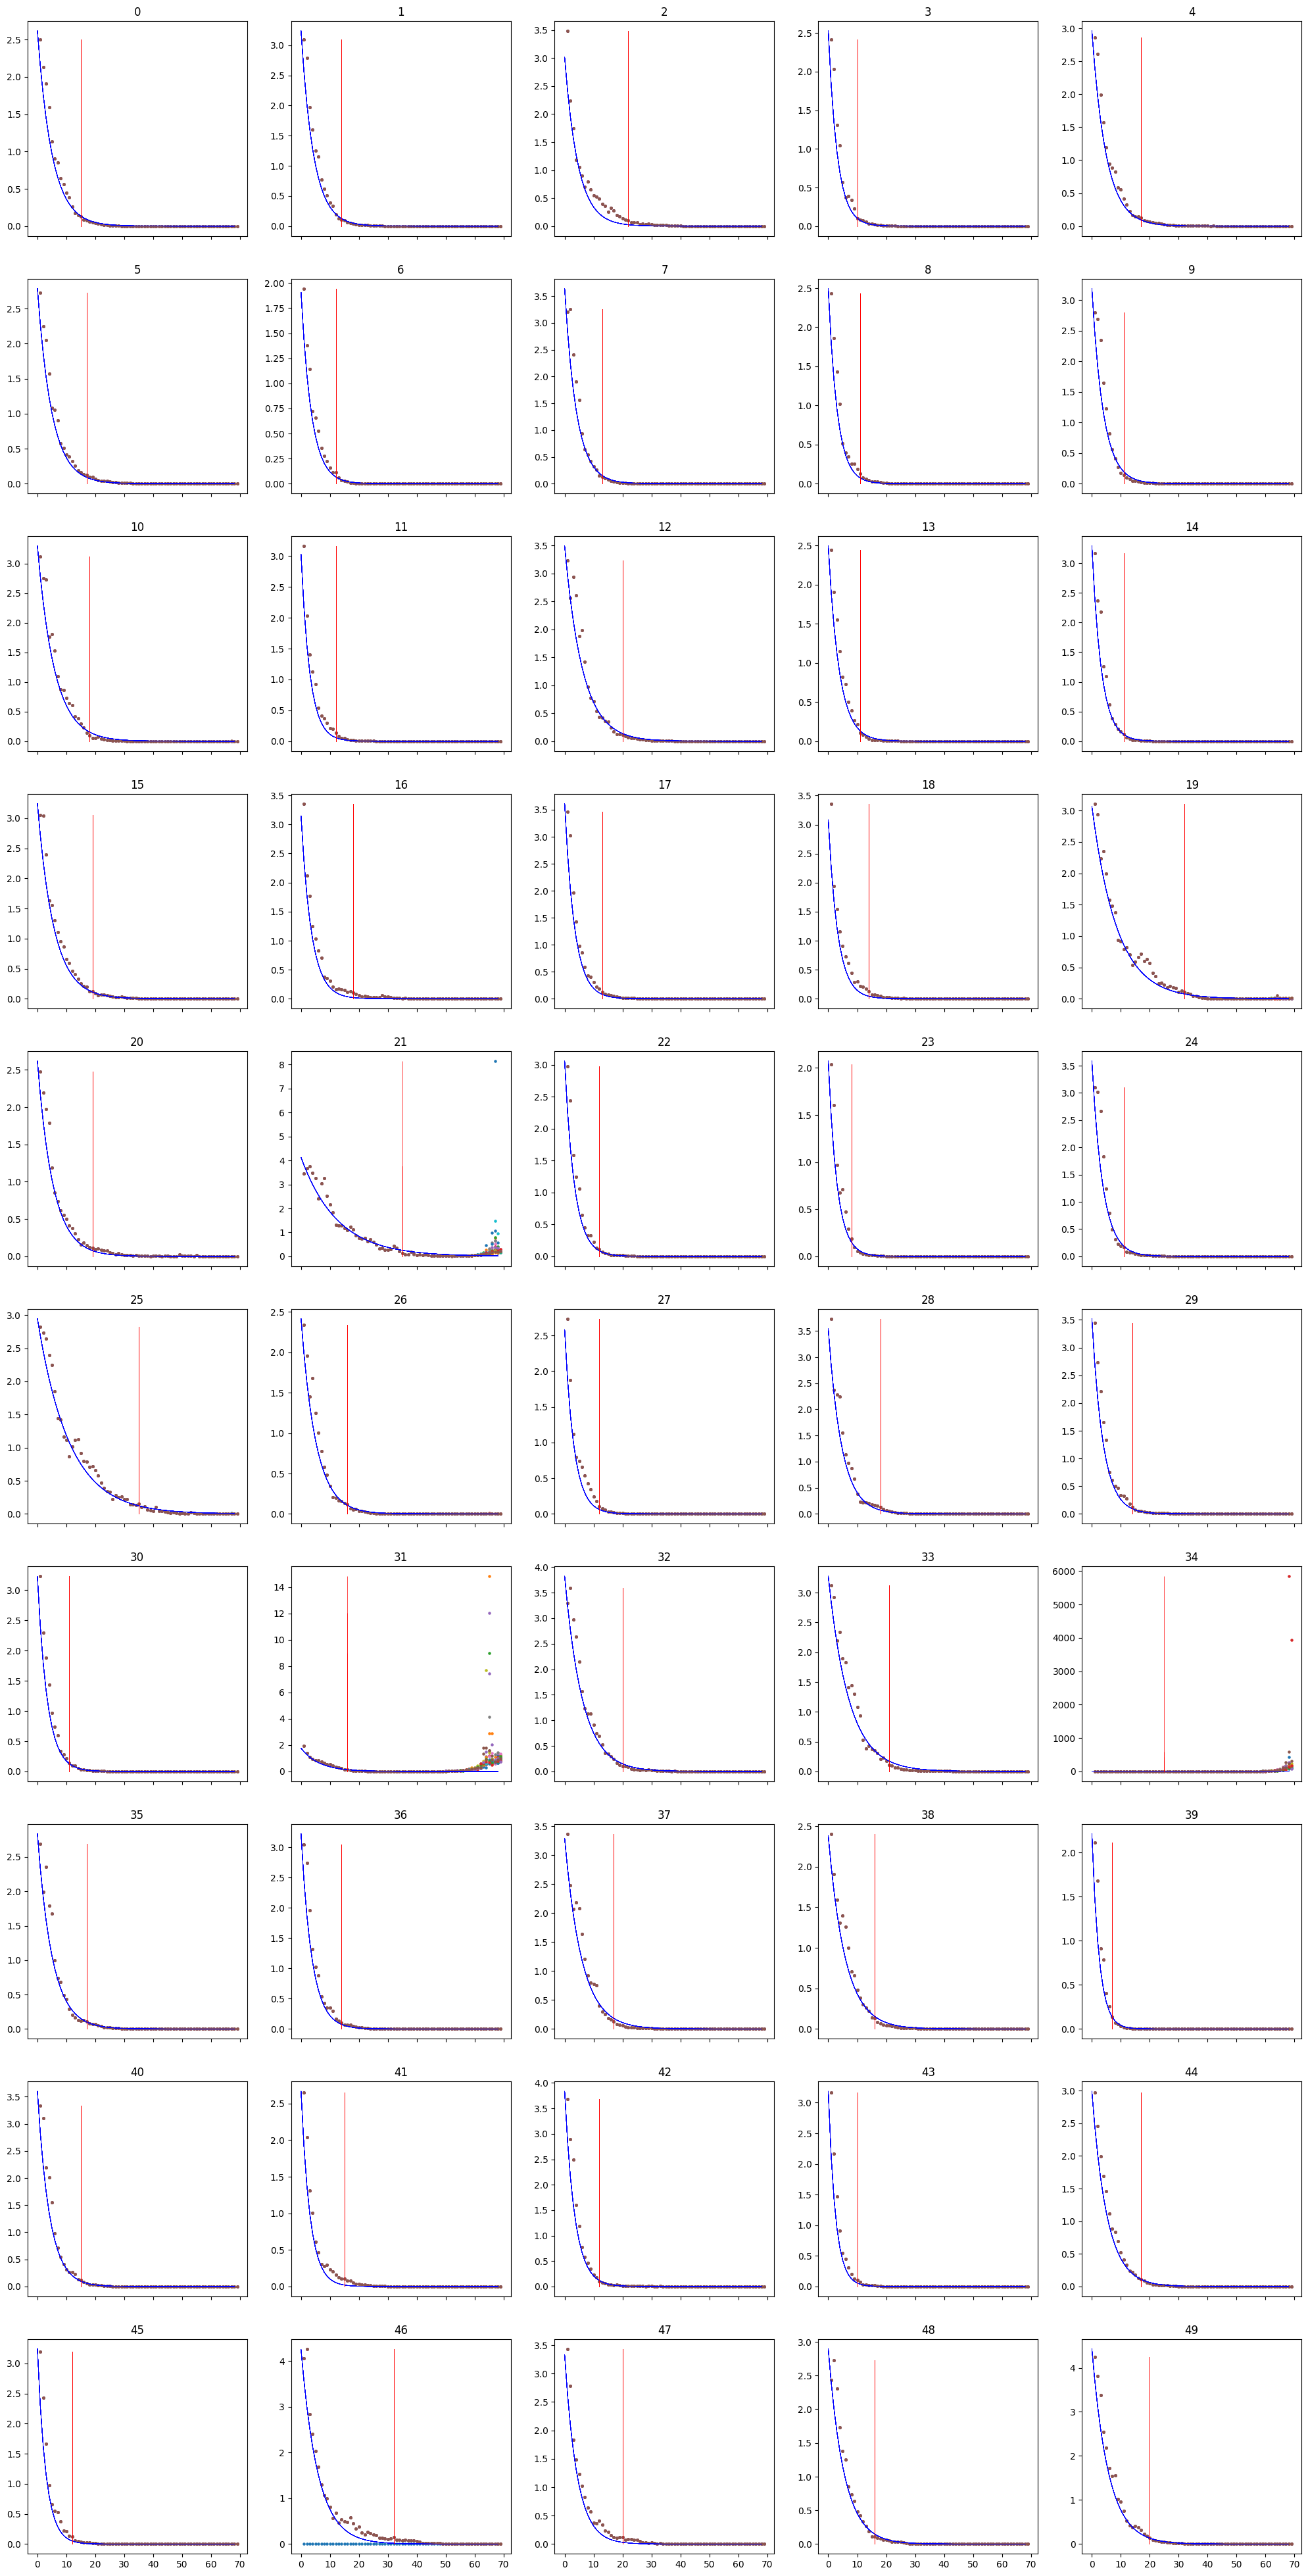

In [14]:
# plot the lengths of the orthogonal vectors but the new vector was not normalized when computing the orthogonal vector
fig, ax = plt.subplots(10,5, figsize=(25,50), sharex=True)
for t in range(50):
    for i in range(Hippo_n_feature):
        ax[t//5, t%5].scatter(x_vals, orth_vec_lens_not_norm[t, i, :], label=f'{i}', s=5)
        ax[t//5, t%5].plot(y_vals_not_norm[t, :], c='b',linewidth=0.5)
        ax[t//5, t%5].set_title(f'{t}')
        ax[t//5, t%5].vlines(thresh_crossed_not_norm[t], ymin=0, ymax=max(orth_vec_lens_not_norm[t, i, :]), colors='r', linewidths=0.5)

In [15]:
# get the trials sorted by their tau values and threshold crossing times
idx_sorted_tau_not_norm = np.argsort(-tau_vals_not_norm)
idx_sorted_thresh_crossed_not_norm = np.argsort(-thresh_crossed_not_norm)

print(idx_sorted_tau_not_norm)
#print(tau_vals[idx_sorted_tau])
print(idx_sorted_thresh_crossed_not_norm)
#print(thresh_crossed[idx_sorted_thresh_crossed])

[34 21 25 19 33 31 12 32 10 37 38 46 49 15 48 20 44 26 35  0  5  4 28  2
  1 47 40  7  9 29 13 24 36  6 16 42 17 30 22 18 14 27  8  3 41 23 11 45
 39 43]
[25 21 19 46 34  2 33 12 32 47 49 20 15 28 16 10 44 37  5  4 35 31 38 48
 26 40  0 41 29 18 36  1  7 17 11 27 22  6 45 42 13  9 24 30 14  8 43  3
 23 39]


In [16]:
# see the stable trials sorted by their tau values and threshold crossing times
stable_trials_idx_not_norm = stable_trials(neuron_norms_for_srs)
print(stable_trials_idx_not_norm)
print('######################################')

m_not_norm = np.isin(idx_sorted_tau_not_norm, stable_trials_idx_not_norm)
stable_sorted_tau_not_norm = idx_sorted_tau_not_norm[m_not_norm]
print(stable_sorted_tau_not_norm)

m_not_norm = np.isin(idx_sorted_thresh_crossed_not_norm, stable_trials_idx_not_norm)
stable_sorted_thresh_not_norm = idx_sorted_thresh_crossed_not_norm[m_not_norm]
print(stable_sorted_thresh_not_norm)

[ 1  3  4  5  6  7  8  9 11 12 13 14 15 17 18 22 23 24 27 28 29 30 33 35
 36 38 39 40 41 42 43 45 47 49]
######################################
[33 12 38 49 15 35  5  4 28  1 47 40  7  9 29 13 24 36  6 42 17 30 22 18
 14 27  8  3 41 23 11 45 39 43]
[33 12 47 49 15 28  5  4 35 38 40 41 29 18 36  1  7 17 11 27 22  6 45 42
 13  9 24 30 14  8 43  3 23 39]


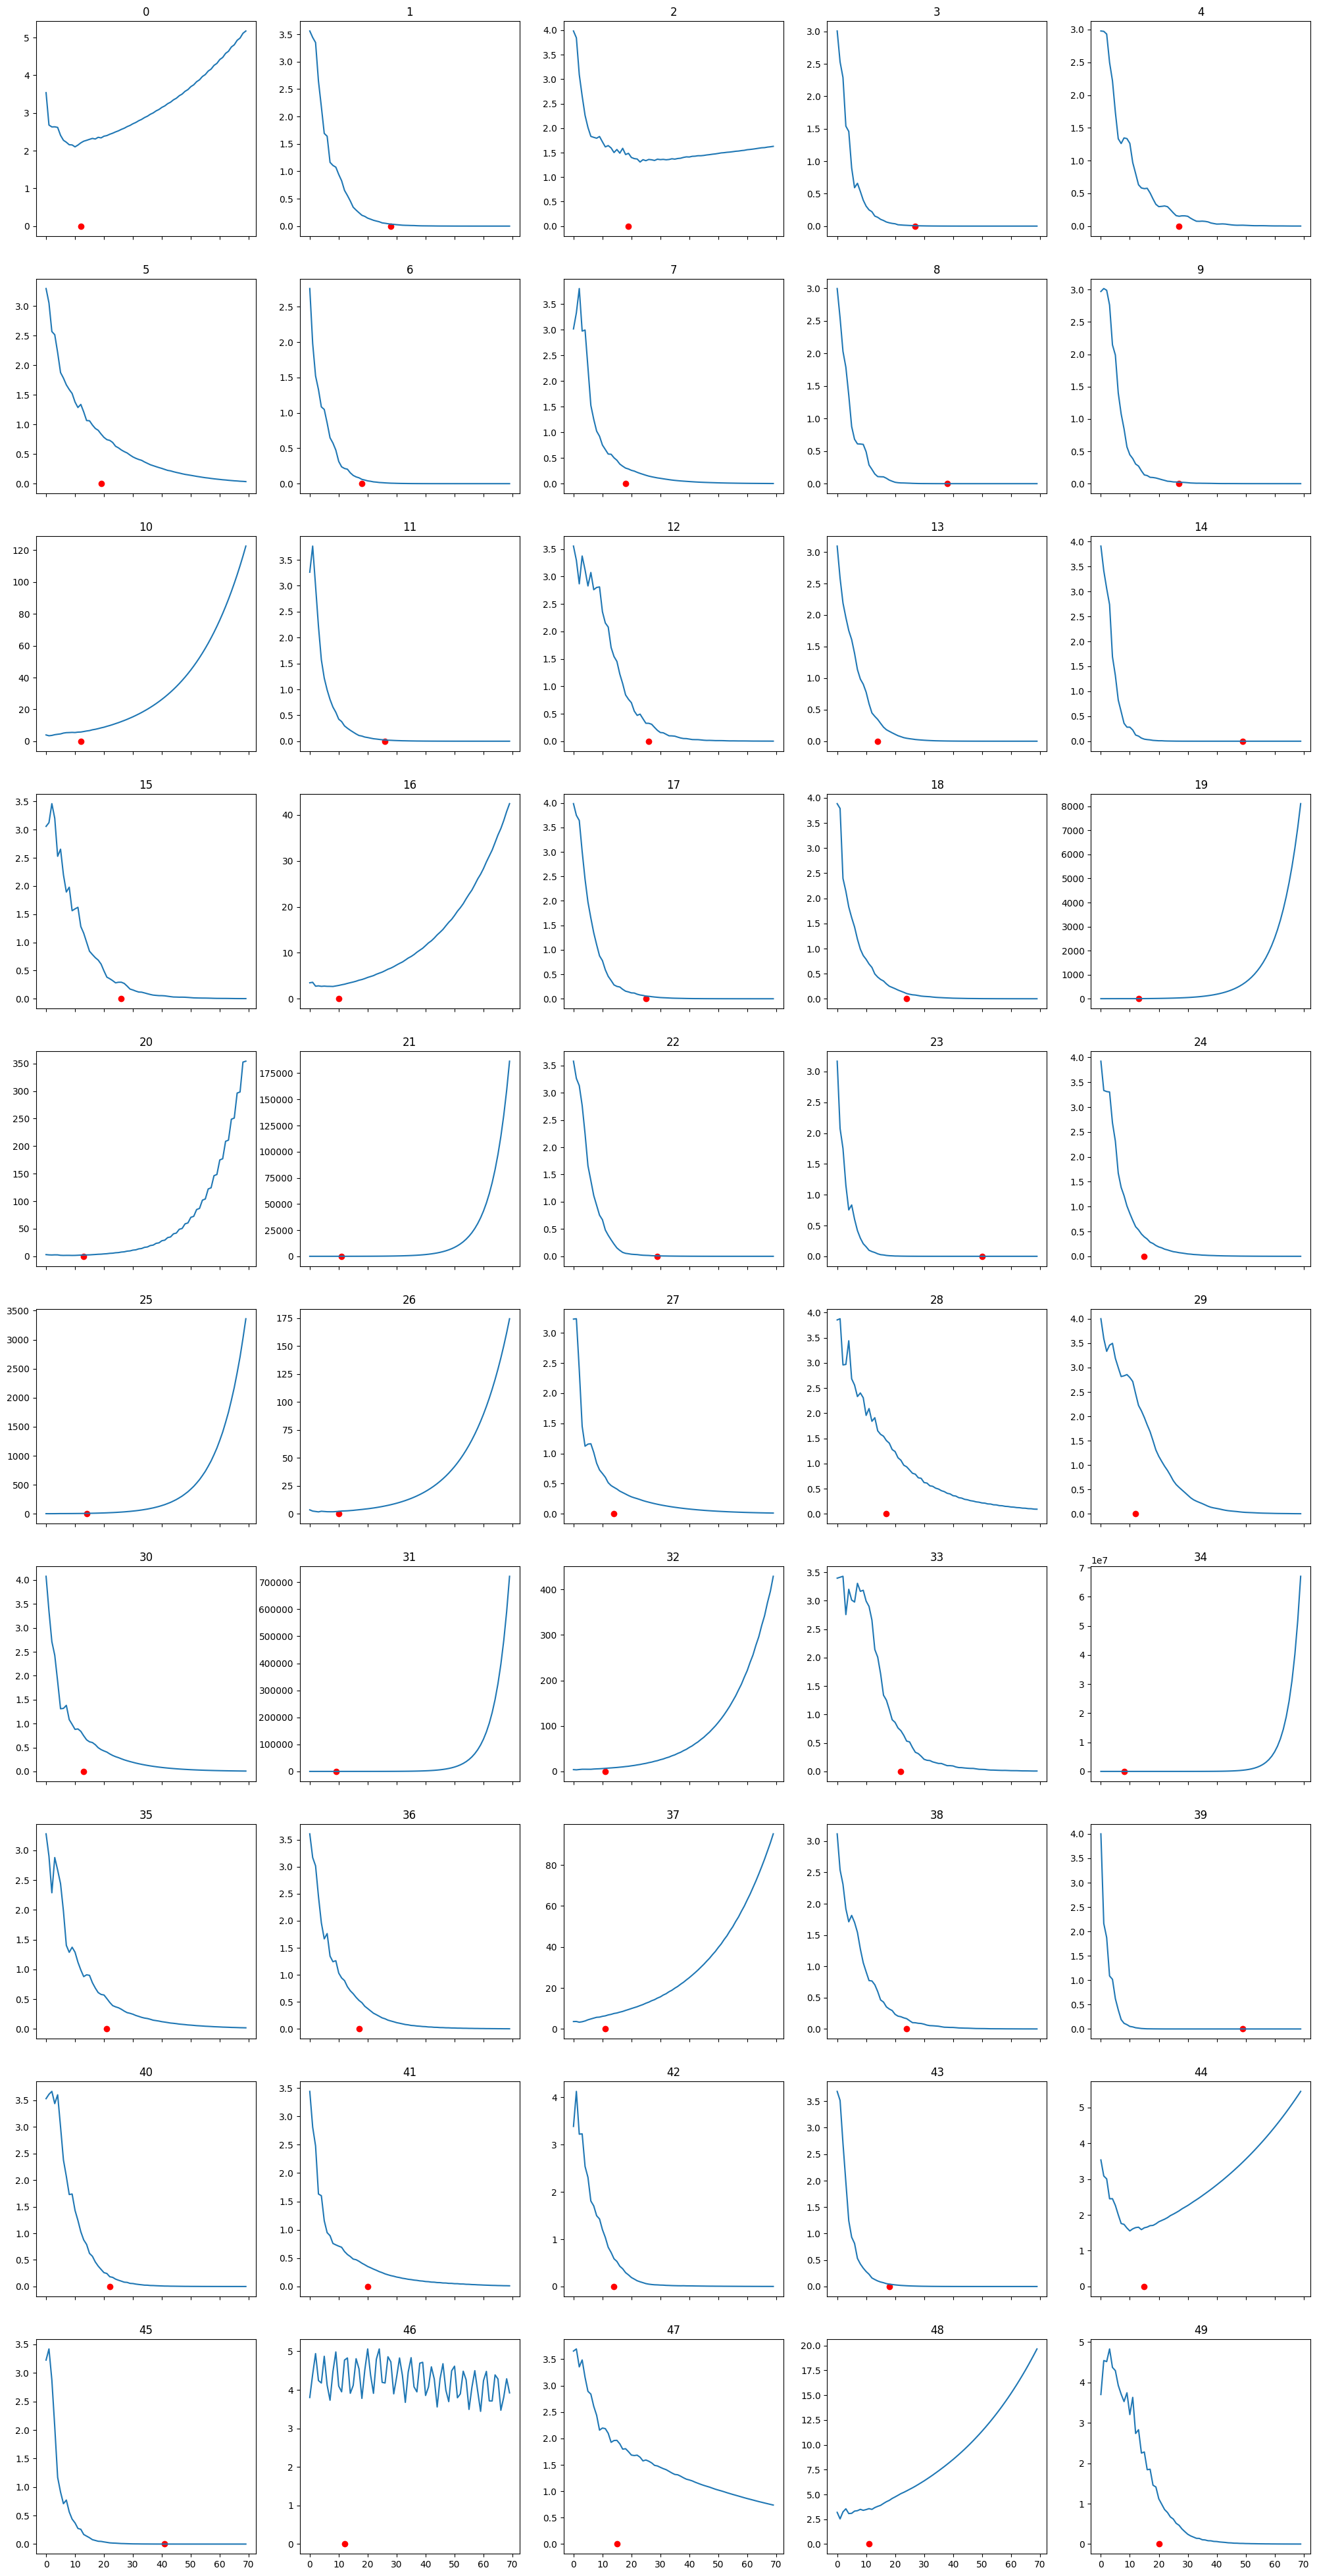

In [17]:
# plot the norms of the different weights
x_vals = np.arange(1,70)
fig, ax = plt.subplots(10,5, figsize=(25,50), sharex=True)
for t in range(50):
    #for i in range(Hippo_n_feature):
    ax[t//5, t%5].plot(neuron_norms_for_srs[t, :])
    ax[t//5, t%5].set_title(f'{t}')
    ax[t//5, t%5].scatter(thresh_crossed[t], 0, c='r')

